In [1]:
import subsetmask as sm
import squidpy as sq
import scanpy as sc

C:\Users\robin\miniconda3\envs\cosmx_python\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
C:\Users\robin\miniconda3\envs\cosmx_python\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
C:\Users\robin\miniconda3\envs\cosmx_python\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


In [2]:
obj = sc.read_h5ad("F:/cosmx_gray/data/gray_lung_slide_1_unprocessed.h5ad")

In [3]:
meta = obj.obs

In [4]:
meta

,fov,Area,AspectRatio,x_FOV_px,y_FOV_px,Width,Height,Mean.PanCK,Max.PanCK,Mean.CD68,...,nCell,nCount,nCountPerCell,nFeaturePerCell,propNegativeCellAvg,complexityCellAvg,errorCtPerCellEstimate,percOfDataFromErrorPerCell,qcFlagsFOV,fov_names
c_1_100_10,100,904,0.28,3038,8,61,17,3633,11528,618,...,1044,511615.0,490.052682,341.115900,0.001383,1.374568,195.186782,0.398298,Pass,fov_1_100
c_1_100_100,100,7195,0.58,38,555,76,132,6092,23024,572,...,1044,511615.0,490.052682,341.115900,0.001383,1.374568,195.186782,0.398298,Pass,fov_1_100
c_1_100_1001,100,7678,0.70,4144,4105,125,87,1513,3132,582,...,1044,511615.0,490.052682,341.115900,0.001383,1.374568,195.186782,0.398298,Pass,fov_1_100
c_1_100_1004,100,2188,0.95,4032,4097,65,62,1601,3648,1373,...,1044,511615.0,490.052682,341.115900,0.001383,1.374568,195.186782,0.398298,Pass,fov_1_100
c_1_100_1005,100,7236,0.93,3960,4134,105,113,3065,21596,704,...,1044,511615.0,490.052682,341.115900,0.001383,1.374568,195.186782,0.398298,Pass,fov_1_100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c_1_70_157,70,3302,0.80,48,1027,83,66,1544,2952,541,...,1107,682876.0,616.870822,467.488708,0.001439,1.257216,248.506098,0.402849,Pass,fov_1_70
c_1_4_186,4,6470,0.95,4173,533,90,95,3647,8628,1550,...,1485,739688.0,498.106397,347.851178,0.002501,1.342452,215.189394,0.432015,Pass,fov_1_4
c_1_70_625,70,5404,0.86,4126,2679,77,90,1022,2720,391,...,1107,682876.0,616.870822,467.488708,0.001439,1.257216,248.506098,0.402849,Pass,fov_1_70
c_1_43_78,43,3740,0.78,2307,354,62,80,1383,3556,448,...,975,429718.0,440.736410,305.785641,0.002143,1.320054,241.933333,0.548930,Pass,fov_1_43


In [ ]:
meta[["CenterX_global_px", "CenterY_global_px"]]



In [4]:
# test
image = sm.Image(metadata_df=meta, 
                  images_col='Run_Tissue_name',
                  image_name='NCL R Gray 08/05/2025',
                  x_col="x_slide_mm",
                  y_col="y_slide_mm")

# addd store image method
image.store_image(group_col=None, figsize=(30, 50), dpi=300, dot_size=5, cmap='tab20')



C:\Users\robin\miniconda3\envs\cosmx_python\Lib\site-packages\PIL\Image.py:3368: DecompressionBombWarning: Image size (135000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


<Labels layer 'Mask' at 0x1a4668addc0>

In [5]:
# launches napari with the generated image
image.draw_labels()


<Labels layer 'Mask' at 0x1a5175ee3f0>

In [6]:

# without closing napari we run this line to save the annotations
image.save_annotations(ann_col_name="samples")

# we change our annotations for something more meaningful
map = {
    "label_1": "sample_1",
    "label_2": "sample_2"
}

image.rename_annotations(ann_col_name="samples", mapping_dict=map)

# we extract the annotated df from the object
annotated_meta = image.annotated_metadata_df

# now just save the annotated metadata
#annotated_meta.to_csv("test/metadata_with_labels.csv")

In [7]:
annotated_meta[["samples"]]

,samples
c_1_100_10,sample_1
c_1_100_100,sample_1
c_1_100_1001,sample_1
c_1_100_1004,sample_1
c_1_100_1005,sample_1
...,...
c_1_70_157,sample_1
c_1_4_186,sample_1
c_1_70_625,sample_1
c_1_43_78,sample_1


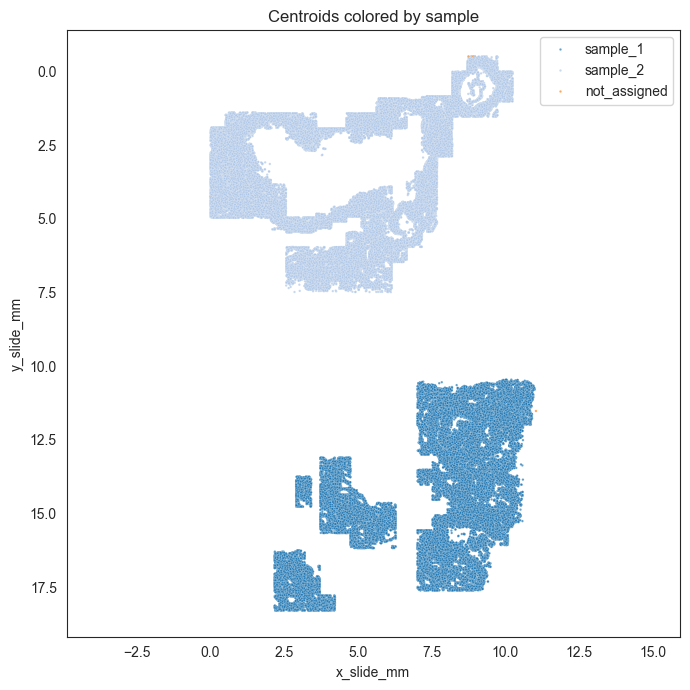

In [11]:
# scater plot using matplot lib
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
sns.set_style("white")
sns.scatterplot(
    data=annotated_meta,
    x="x_slide_mm",
    y="y_slide_mm",
    hue="samples",        # or "library_id", etc.
    s=3,
    alpha=0.7,
    palette="tab20"      # or any seaborn/matplotlib palette
)
plt.gca().invert_yaxis()
plt.axis("equal")
plt.title("Centroids colored by sample")
plt.legend(loc='best', bbox_to_anchor=(1, 1))  # move legend outside if crowded
plt.tight_layout()
plt.show()


In [10]:
# replcae the metadata in teh original object
obj.obs = annotated_meta

In [11]:
obj

AnnData object with n_obs × n_vars = 347794 × 6175
    obs: 'fov', 'Area', 'AspectRatio', 'x_FOV_px', 'y_FOV_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68', 'Max.CD68', 'Mean.Membrane', 'Max.Membrane', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'SplitRatioToLocal', 'NucArea', 'NucAspectRatio', 'Circularity', 'Eccentricity', 'Perimeter', 'Solidity', 'cell_id', 'assay_type', 'version', 'Run_Tissue_name', 'Panel', 'cellSegmentationSetId', 'cellSegmentationSetName', 'slide_ID_numeric', 'x_slide_mm', 'y_slide_mm', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quant

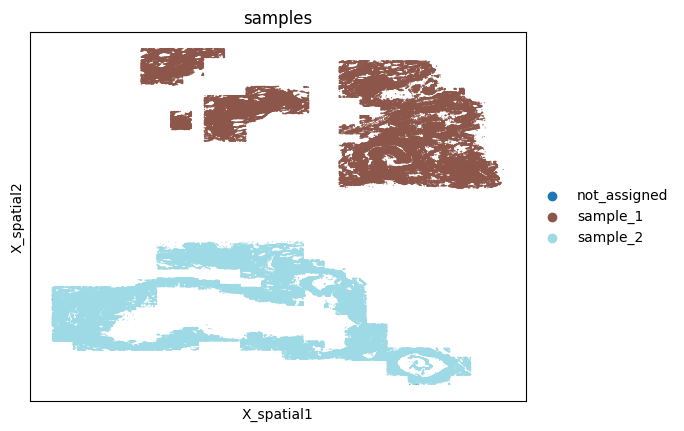

In [14]:
sc.pl.embedding(obj, basis = "X_spatial", color="samples", size=3, alpha=0.7, palette="tab20")

In [15]:
obj.obsm["X_spatial"]

array([[ 7.38597256, 11.97376713],
       [ 7.02512973, 11.90797345],
       [ 7.51900329, 11.4809761 ],
       ...,
       [ 9.56450101, 14.2120752 ],
       [ 8.83379428, 17.05130688],
       [ 1.71436429,  3.08550087]])

now with full data

In [ ]:
obj.obs = annotated_meta

In [29]:
annotated_meta

,fov,Area,AspectRatio,x_FOV_px,y_FOV_px,Width,Height,Mean.PanCK,Max.PanCK,Mean.CD68,...,nCount,nCountPerCell,nFeaturePerCell,propNegativeCellAvg,complexityCellAvg,errorCtPerCellEstimate,percOfDataFromErrorPerCell,qcFlagsFOV,fov_names,samples
c_1_100_10,100,904,0.28,3038,8,61,17,3633,11528,618,...,511615.0,490.052682,341.115900,0.001383,1.374568,195.186782,0.398298,Pass,fov_1_100,sample_1
c_1_100_100,100,7195,0.58,38,555,76,132,6092,23024,572,...,511615.0,490.052682,341.115900,0.001383,1.374568,195.186782,0.398298,Pass,fov_1_100,sample_1
c_1_100_1001,100,7678,0.70,4144,4105,125,87,1513,3132,582,...,511615.0,490.052682,341.115900,0.001383,1.374568,195.186782,0.398298,Pass,fov_1_100,sample_1
c_1_100_1004,100,2188,0.95,4032,4097,65,62,1601,3648,1373,...,511615.0,490.052682,341.115900,0.001383,1.374568,195.186782,0.398298,Pass,fov_1_100,sample_1
c_1_100_1005,100,7236,0.93,3960,4134,105,113,3065,21596,704,...,511615.0,490.052682,341.115900,0.001383,1.374568,195.186782,0.398298,Pass,fov_1_100,sample_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c_1_70_157,70,3302,0.80,48,1027,83,66,1544,2952,541,...,682876.0,616.870822,467.488708,0.001439,1.257216,248.506098,0.402849,Pass,fov_1_70,sample_1
c_1_4_186,4,6470,0.95,4173,533,90,95,3647,8628,1550,...,739688.0,498.106397,347.851178,0.002501,1.342452,215.189394,0.432015,Pass,fov_1_4,sample_1
c_1_70_625,70,5404,0.86,4126,2679,77,90,1022,2720,391,...,682876.0,616.870822,467.488708,0.001439,1.257216,248.506098,0.402849,Pass,fov_1_70,sample_1
c_1_43_78,43,3740,0.78,2307,354,62,80,1383,3556,448,...,429718.0,440.736410,305.785641,0.002143,1.320054,241.933333,0.548930,Pass,fov_1_43,sample_1


In [34]:
obj.uns["samples_colors"]

['#1f77b4', '#8c564b', '#9edae5']

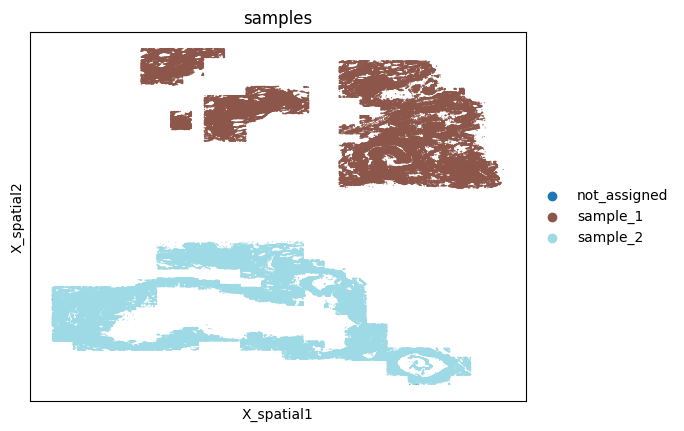

In [37]:
sc.pl.embedding(obj, basis = "X_spatial", color="samples", size=3, alpha=0.7, palette=obj.uns["samples_colors"])

In [31]:
sq.pl.spatial_scatter(obj_full, spatial_key = "spatial_fov" ,color="samples", size=3, alpha=0.7, palette="tab20")

KeyError: "Spatial key 'spatial_fov' not found in `adata.uns`."